# Phase 2 (part 09): the evaluation protocol on a second dataset (UNSW-NB15) and a second model class (XGBoost)

**What this is.** The first breadth notebook. It applies the Phase-1 evaluation protocol —
geometry characterization + the controlled, known-ground-truth localization test — to
**UNSW-NB15** and across **RandomForest and XGBoost**, to answer the two questions that
decide whether the Phase-1 picture generalizes:

1. **Is the CICIDS structural block dataset-specific?** On CICIDS, no decorrelated-and-
   non-degenerate feature set exists (median redundancy 0.95; the decorrelated features are
   constant), so an identifiable localization target is unconstructable (07h). UNSW may be
   less collinear. We characterize UNSW's redundancy + degeneracy and ask the reachability
   question head-to-head with CICIDS.
2. **Does the identifiability mechanism hold on real data, when the geometry permits the
   test?** 07g confirmed it synthetically (proxy-free target -> SHAP recovers; proxies ->
   degrade), but CICIDS could not run the clean real-data version. If UNSW reaches the
   decorrelated-and-non-degenerate regime, we run the leakage->recovery sweep there on real
   features — the test CICIDS structurally forbade — for both model classes.

**Method (unchanged from 07h, so results are directly comparable).** Controlled concept arm
on real UNSW features: P(X) held stable, a synthetic relevance swap S1 -> S2 with **known**
S2, recover S2 by precision@K. Ground truth is known by construction, so we avoid the
ground-truth crisis of 07c/07d. Non-degenerate features only (median-split labels are then
learnable). KS carried as the concept-blind baseline. Aux model is **both** RF and XGBoost.

**Scope note (deliberate).** This notebook is the *controlled, known-GT* test. The
*real-attack-family-holdout distributional benchmark* (KS vs SHAP on UNSW's actual drift,
replicating the redundancy benchmark) is the **next** notebook — it reintroduces the
real-data ground-truth problem and must not be entangled with the clean test here. Same
split discipline as 07 (localization) vs 08 (adaptation).

**Pre-registered cross-dataset gate (D025).**
- *CROSS-DATASET-BLOCK* — UNSW also cannot reach a decorrelated-and-non-degenerate set
  (leakage floor > 0.20). The structural block generalizes; explanation localization is
  structurally hard across IDS datasets. The negative is now cross-dataset.
- *MECHANISM-HOLDS-ON-REAL-DATA* — UNSW reaches the regime and aux-SHAP recovers there with
  a valid (learnable) model, for at least one model class. The identifiability mechanism is
  validated on real data; a conditions-of-validity result with a genuine real positive pole
  and a clean leakage->recovery curve.
- *SECOND-FACTOR-CONFIRMED* — UNSW reaches the regime, the model learns it (valid recall),
  yet aux-SHAP fails. Real evidence of a second factor beyond correlation; qualifies the
  synthetic mechanism on real data.

Numbering: 08 is reserved for the deferred adaptation/efficiency experiment; this is the
first Phase-2 notebook (09).

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import sys, glob
sys.path.insert(0, '/content/drive/MyDrive/phd_thesis')
%pip install -q shap xgboost

import time, json, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

from src.utils.seeding import set_global_seed
from src.utils.documentation import log_finding, add_journal_entry
from src.divergence.localization import (
    shap_importance, ks_drift_scores, topk_indices, precision_at_k,
    random_precision_expectation,
)

ROOT = Path('/content/drive/MyDrive/phd_thesis')
FIGURES = ROOT / 'reports' / 'figures'
TABLES = ROOT / 'reports' / 'tables'
DECISIONS_LOG = ROOT / 'reports' / 'advisor_notes' / 'decisions_log.md'
SUMMARY_JSON = ROOT / 'data' / 'processed' / 'phase2_09_unsw_geometry.json'
for p in (FIGURES, TABLES):
    p.mkdir(parents=True, exist_ok=True)

with open(ROOT / 'data' / 'processed' / 'phase1_06_metadata.json') as f:
    meta06 = json.load(f)
RF_PARAMS = meta06['rf_hyperparameters']

# CICIDS reference (documented from 07h, for the cross-dataset comparison)
CIC_REF = {'name': 'CICIDS2017', 'n_features': 82, 'median_redundancy': 0.95,
           'nondegen': 63, 'leakage_floor': 0.248, 'reached': False}

PAPER_RCPARAMS = {
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05, 'savefig.facecolor': 'white',
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'font.family': 'serif', 'font.serif': ['DejaVu Serif', 'Times New Roman'],
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 9,
    'axes.linewidth': 0.8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linewidth': 0.5,
    'lines.linewidth': 1.8, 'lines.markersize': 6, 'pdf.fonttype': 42, 'ps.fonttype': 42,
}
mpl.rcParams.update(PAPER_RCPARAMS)
MODEL_COLOR = {'rf': '#E69F00', 'xgb': '#009E73', 'ks': '#0072B2'}

def save_figure(fig, name):
    fig.savefig(FIGURES / f'{name}.png'); fig.savefig(FIGURES / f'{name}.pdf')
    print(f'  saved: {name}.png / .pdf')

def log_decision(decision_id, decision, rationale, alternatives='',
                 context='09_unsw_geometry_localization'):
    today = datetime.date.today().isoformat()
    if DECISIONS_LOG.exists() and f'## {decision_id} \u2014' in DECISIONS_LOG.read_text():
        print(f'[DECISION SKIPPED] {decision_id} already logged.'); return
    entry = (f'\n## {decision_id} \u2014 {today}\n**Context:** `{context}`\n\n'
             f'**Decision:** {decision}\n\n**Rationale:** {rationale}\n\n')
    if alternatives:
        entry += f'**Alternatives considered:** {alternatives}\n'
    with open(DECISIONS_LOG, 'a') as f:
        f.write(entry)
    print(f'[DECISION LOGGED] {decision_id}')

print('Setup complete.')

Setup complete.


## 2. D025 — the cross-dataset protocol and the pre-registered gate

In [14]:
log_decision(
    decision_id='D025',
    decision=(
        'Apply the Phase-1 evaluation protocol to UNSW-NB15 and across RF + XGBoost. '
        '(1) Characterize UNSW geometry: per-feature redundancy (max |corr|) and degeneracy '
        '(modal fraction, distinct count); compare head-to-head with CICIDS. (2) Reachability: '
        'among non-degenerate UNSW features, sweep relevant sets across redundancy quantiles '
        'and report achieved external leakage per level -- can UNSW reach external leakage '
        '<= 0.20 (a decorrelated-and-informative set), which CICIDS could not? (3) Controlled '
        'leakage->recovery test on real UNSW features (known S2, concept arm, recover S2), '
        'aux model = RF and XGBoost, KS as the concept-blind baseline, gating each level on '
        'aux-recall >= RECALL_MIN and label balance. '
        'Pre-registered cross-dataset gate (committed before execution): '
        'CROSS-DATASET-BLOCK iff the lowest achievable non-degenerate external leakage > 0.20 '
        '(structural block generalizes). MECHANISM-HOLDS-ON-REAL-DATA iff UNSW reaches leakage '
        '<= 0.20 AND aux-SHAP precision >= 0.50 there with valid recall, for >= 1 model class '
        '(mechanism validated on real data). SECOND-FACTOR-CONFIRMED iff UNSW reaches <= 0.20 '
        'with valid recall but aux-SHAP < 0.50 (clean target, learned model, SHAP fails). '
        'Report RF vs XGBoost agreement as the model-breadth sub-result.'
    ),
    rationale=(
        'CICIDS could not test the identifiability mechanism on real data (no decorrelated-'
        'and-non-degenerate set; 07h). UNSW has a different, possibly less collinear geometry. '
        'This determines whether the structural block is dataset-specific or general, whether '
        'the mechanism holds on real data when constructible, and whether the picture is '
        'model-class-dependent (RF vs XGBoost) -- the breadth a Q1 cross-dataset claim needs. '
        'Known-GT construction avoids the ground-truth crisis of 07c/07d.'
    ),
    alternatives=(
        'Real attack-family-holdout distributional drift on UNSW (deferred to the next '
        'notebook: reintroduces the real-data ground-truth problem; must not contaminate the '
        'clean known-GT test). One-hot encoding categorical UNSW features (rejected here: '
        'changes the redundancy structure; the geometry question is about numeric features, '
        'consistent with the CICIDS analysis).'
    ),
)

[DECISION SKIPPED] D025 already logged.


## 3. Configuration

Same controlled-test constants as 07h, for apples-to-apples comparison. The non-degeneracy
filter (modal <= 0.90, distinct >= 20) matches 07h so the cross-dataset numbers are
comparable; counts are reported across a grid in case UNSW's count-features need a different
line. `chance` is computed from UNSW's actual feature count after loading.

In [15]:
set_global_seed(42)

N_POOL = 40000
ARM_N = 8000
REL_SIZE = 5
GT_SIZE = REL_SIZE
K_PRIMARY = REL_SIZE
SHAP_SAMPLE = 1500
SEEDS = [42, 1, 7]
LEVEL_QUANTILES = [0.05, 0.35, 0.65, 0.95]   # redundancy quantiles among NON-DEGENERATE feats
MODELS = ['rf', 'xgb']
MODAL_MAX = 0.90
MIN_DISTINCT = 20
MODAL_GRID = [0.80, 0.90, 0.95, 0.99]
REAL_DECORR_MAX = 0.20    # decorrelated iff external leakage <= this
RECOVER_MIN = 0.50        # SHAP recovery bar
RECALL_MIN = 0.70         # construction-validity gate
BALANCE_BAND = (0.2, 0.8)

# optional manual override; leave None to auto-detect the UNSW file on Drive
UNSW_PATH = '/content/drive/MyDrive/phd_thesis/data/processed/unsw_nb15/UNSW_NB15_training-set.parquet'

print(f'Levels (redundancy quantiles among non-degenerate): {LEVEL_QUANTILES}')
print(f'Models: {MODELS}.  Non-degenerate iff modal <= {MODAL_MAX} and distinct >= {MIN_DISTINCT}.')
print(f'CROSS-DATASET-BLOCK iff min non-degenerate external leakage > {REAL_DECORR_MAX}.')

Levels (redundancy quantiles among non-degenerate): [0.05, 0.35, 0.65, 0.95]
Models: ['rf', 'xgb'].  Non-degenerate iff modal <= 0.9 and distinct >= 20.
CROSS-DATASET-BLOCK iff min non-degenerate external leakage > 0.2.


## 4. Load UNSW-NB15 and build the numeric feature pool

Auto-detects the UNSW file under `data/processed` / `data/raw` (override `UNSW_PATH` if
needed). Categorical columns (proto/service/state) and id/label/attack_cat are dropped; the
geometry analysis is over numeric features, consistent with the CICIDS analysis. The schema
and the kept/dropped columns are printed so you can verify the load before trusting anything
downstream.

In [16]:
def find_unsw():
    pats = []
    for d in (ROOT / 'data' / 'processed', ROOT / 'data' / 'raw'):
        for ext in ('parquet', 'csv'):
            pats += glob.glob(str(d / f'*[uU][nN][sS][wW]*.{ext}'))
    return sorted(set(pats))

cands = find_unsw()
print('UNSW file candidates:')
for c in cands:
    print('   ', c)
path = UNSW_PATH or next((c for c in cands if 'train' in c.lower()), (cands[0] if cands else None))
assert path is not None, ('No UNSW file found under data/processed or data/raw. '
                          'Set UNSW_PATH in the config cell to the correct file.')
print('\nUsing:', path)
df = pd.read_parquet(path) if str(path).endswith('parquet') else pd.read_csv(path)
print('raw shape:', df.shape)

EXCLUDE = {'id', 'label', 'attack_cat', 'attack_category', 'target', 'index', 'unnamed: 0'}
numeric = df.select_dtypes(include=[np.number])
feat_cols = [c for c in numeric.columns if str(c).strip().lower() not in EXCLUDE]
dropped = [c for c in df.columns if c not in feat_cols]
Xraw = numeric[feat_cols].to_numpy(dtype=float)
finite = np.isfinite(Xraw).all(axis=1)
Xraw = Xraw[finite]
ridx = np.random.default_rng(42).choice(len(Xraw), size=min(N_POOL, len(Xraw)), replace=False)
Xp = Xraw[ridx]
N_FEATURES = Xp.shape[1]
FEATURE_COLS = list(feat_cols)
mu, sd = Xp.mean(0), Xp.std(0); sd[sd == 0] = 1.0
POOL = (Xp - mu) / sd
CHANCE = random_precision_expectation(GT_SIZE, N_FEATURES)

print(f'\nKept {N_FEATURES} numeric features; dropped {len(dropped)} cols '
      f'(categorical/id/label): {dropped}')
print(f'Pool: {POOL.shape} (sampled, finite rows). Chance precision@{K_PRIMARY} = {CHANCE:.3f}.')

UNSW file candidates:

Using: /content/drive/MyDrive/phd_thesis/data/processed/unsw_nb15/UNSW_NB15_training-set.parquet
raw shape: (82332, 46)

Kept 42 numeric features; dropped 4 cols (categorical/id/label): ['source_file', 'label', 'attack_category', 'attempted']
Pool: (40000, 42) (sampled, finite rows). Chance precision@5 = 0.119.


## 5. Characterize UNSW geometry and compare to CICIDS

The cross-dataset comparison is the core payload: if UNSW's redundancy distribution is
shifted left of CICIDS (median 0.95) and it has more low-redundancy non-degenerate features,
it can reach the regime CICIDS could not.

In [17]:
C = np.abs(np.corrcoef(POOL, rowvar=False)); np.fill_diagonal(C, 0.0); C = np.nan_to_num(C)
REDUNDANCY = C.max(axis=1)
PARTNER = np.argmax(C, axis=1)

MODAL_FRAC = np.zeros(N_FEATURES)
N_DISTINCT = np.zeros(N_FEATURES, dtype=int)
for j in range(N_FEATURES):
    vals, cnts = np.unique(Xp[:, j], return_counts=True)
    MODAL_FRAC[j] = cnts.max() / len(Xp)
    N_DISTINCT[j] = len(vals)
NONDEGEN = (MODAL_FRAC <= MODAL_MAX) & (N_DISTINCT >= MIN_DISTINCT)

unsw_med = float(np.median(REDUNDANCY))
unsw_nd = int(NONDEGEN.sum())
print('UNSW vs CICIDS geometry:')
cmp = pd.DataFrame({
    'dataset': ['UNSW-NB15', 'CICIDS2017'],
    'n_features': [N_FEATURES, CIC_REF['n_features']],
    'median_redundancy': [round(unsw_med, 3), CIC_REF['median_redundancy']],
    'non_degenerate': [f'{unsw_nd}/{N_FEATURES}', f"{CIC_REF['nondegen']}/{CIC_REF['n_features']}"],
})
print(cmp.to_string(index=False))
print('\nUNSW non-degenerate count vs modal-fraction threshold (distinct >= %d):' % MIN_DISTINCT)
for t in MODAL_GRID:
    print(f'  modal <= {t:.2f}: {int(((MODAL_FRAC <= t) & (N_DISTINCT >= MIN_DISTINCT)).sum())}')
print(f'\nUNSW non-degenerate features with redundancy < {REAL_DECORR_MAX}: '
      f'{int((NONDEGEN & (REDUNDANCY < REAL_DECORR_MAX)).sum())} '
      f'(need >= {GT_SIZE} for a decorrelated set)')
cmp.to_csv(TABLES / '09_unsw_vs_cicids_geometry.csv', index=False)

UNSW vs CICIDS geometry:
   dataset  n_features  median_redundancy non_degenerate
 UNSW-NB15          42              0.903          29/42
CICIDS2017          82              0.950          63/82

UNSW non-degenerate count vs modal-fraction threshold (distinct >= 20):
  modal <= 0.80: 29
  modal <= 0.90: 29
  modal <= 0.95: 30
  modal <= 0.99: 30

UNSW non-degenerate features with redundancy < 0.2: 0 (need >= 5 for a decorrelated set)


## 6. Reachability — select non-degenerate sets across redundancy quantiles

For each redundancy quantile we pick `GT_SIZE` non-degenerate features near that level
(strongest partner held outside, so high-redundancy sets get genuinely high external
leakage). The achieved leakage per level is the x-axis of the recovery curve; the minimum
is the decisive reachability number.

In [18]:
def external_leakage(S):
    S = list(S); mask = np.ones(N_FEATURES, bool); mask[S] = False
    return float(np.mean([C[i, mask].max() for i in S]))

def select_nd(quantile):
    nd = np.where(NONDEGEN)[0]
    if len(nd) < GT_SIZE:
        return nd
    target = np.quantile(REDUNDANCY[nd], quantile)
    order = nd[np.argsort(np.abs(REDUNDANCY[nd] - target), kind='stable')]
    S, forbidden = [], set()
    for i in order:
        i = int(i)
        if i in forbidden or i in S:
            continue
        S.append(i); forbidden.add(int(PARTNER[i]))
        if len(S) == GT_SIZE:
            break
    if len(S) < GT_SIZE:
        for i in order:
            if int(i) not in S:
                S.append(int(i))
                if len(S) == GT_SIZE:
                    break
    return np.array(S)

LEVEL_SETS = {q: select_nd(q) for q in LEVEL_QUANTILES}
LEVEL_LEAK = {q: external_leakage(S) for q, S in LEVEL_SETS.items()}
print('Achieved external leakage by level (non-degenerate sets):')
for q in LEVEL_QUANTILES:
    print(f'  quantile {q:.2f}: leakage = {LEVEL_LEAK[q]:.3f}  '
          f'(features: {[FEATURE_COLS[int(i)] for i in LEVEL_SETS[q]]})')
min_leak = min(LEVEL_LEAK.values())
print(f'\nMinimum achievable non-degenerate leakage = {min_leak:.3f}  '
      f'(REACHED decorrelated <= {REAL_DECORR_MAX}: {min_leak <= REAL_DECORR_MAX})')
print(f'CICIDS reference: leakage floor {CIC_REF["leakage_floor"]} (reached: {CIC_REF["reached"]})')

Achieved external leakage by level (non-degenerate sets):
  quantile 0.05: leakage = 0.444  (features: ['dur', 'smean', 'dload', 'rate', 'proto'])
  quantile 0.35: leakage = 0.818  (features: ['dtcpb', 'stcpb', 'dinpkt', 'ackdat', 'ct_dst_sport_ltm'])
  quantile 0.65: leakage = 0.944  (features: ['sinpkt', 'ct_dst_src_ltm', 'ct_src_dport_ltm', 'tcprtt', 'ct_src_ltm'])
  quantile 0.95: leakage = 0.985  (features: ['dbytes', 'sloss', 'dpkts', 'spkts', 'ct_srv_dst'])

Minimum achievable non-degenerate leakage = 0.444  (REACHED decorrelated <= 0.2: False)
CICIDS reference: leakage floor 0.248 (reached: False)


## 7. Leakage->recovery sweep on real UNSW features (RF + XGBoost)

The test CICIDS could not run. For each level, both model classes, and three seeds: build
the concept arm on real UNSW features, train the aux model, and measure SHAP recovery of the
known relevant set, gated on recall + balance. KS is the concept-blind baseline.

In [19]:
def _labels(X, w):
    s = X @ w
    return (s > np.median(s)).astype(int)

def build_concept_arm(S2, seed):
    r = np.random.default_rng(seed)
    rows_ = r.permutation(len(POOL))
    X_pre, X_post = POOL[rows_[:ARM_N]].copy(), POOL[rows_[ARM_N:2 * ARM_N]].copy()
    others = [i for i in range(N_FEATURES) if i not in set(int(j) for j in S2)]
    S1 = r.choice(others, size=REL_SIZE, replace=False)
    w1 = np.zeros(N_FEATURES); w1[S1] = r.normal(size=REL_SIZE)
    w2 = np.zeros(N_FEATURES); w2[list(S2)] = r.normal(size=REL_SIZE)
    return X_pre, _labels(X_pre, w1), X_post, _labels(X_post, w2)

def make_model(kind, seed):
    if kind == 'rf':
        return RandomForestClassifier(**{**RF_PARAMS, 'random_state': seed})
    from xgboost import XGBClassifier
    return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                         subsample=0.9, colsample_bytree=0.9, n_jobs=-1,
                         tree_method='hist', random_state=seed, eval_metric='logloss')

rows = []
t0 = time.time()
for q in LEVEL_QUANTILES:
    S2 = LEVEL_SETS[q]; gt = set(int(i) for i in S2); leak = LEVEL_LEAK[q]
    for seed in SEEDS:
        X_pre, y_pre, X_post, y_post = build_concept_arm(S2, seed)
        tr, ev = train_test_split(
            np.arange(len(y_post)), train_size=0.7,
            stratify=y_post if len(np.unique(y_post)) > 1 else None, random_state=seed)
        bal = float(np.mean(y_post[ev]))
        sidx = np.random.default_rng(seed).choice(ev, size=min(SHAP_SAMPLE, len(ev)), replace=False)
        # model-independent baselines, once per (level, seed)
        ks = ks_drift_scores(X_pre, X_post)
        rnd = np.random.default_rng(seed).random(N_FEATURES)
        rows.append({'level': q, 'leakage': leak, 'seed': seed, 'model': 'shared',
                     'method': 'ks', 'precision': precision_at_k(ks, gt, K_PRIMARY),
                     'aux_recall': float('nan'), 'balance': bal})
        rows.append({'level': q, 'leakage': leak, 'seed': seed, 'model': 'shared',
                     'method': 'random', 'precision': precision_at_k(rnd, gt, K_PRIMARY),
                     'aux_recall': float('nan'), 'balance': bal})
        for model in MODELS:
            aux = make_model(model, seed).fit(X_post[tr], y_post[tr])
            rec = (recall_score(y_post[ev], aux.predict(X_post[ev]), zero_division=0)
                   if len(np.unique(y_post[ev])) > 1 else float('nan'))
            imp = shap_importance(aux, X_post[sidx])
            rows.append({'level': q, 'leakage': leak, 'seed': seed, 'model': model,
                         'method': 'aux_shap', 'precision': precision_at_k(imp, gt, K_PRIMARY),
                         'aux_recall': rec, 'balance': bal})
    print(f'  level q={q:.2f} (leak {leak:.2f}) done  ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows)
res.to_csv(TABLES / '09_unsw_sweep_raw.csv', index=False)
print(f'\n{len(res)} rows.')

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  level q=0.05 (leak 0.44) done  (32s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  level q=0.35 (leak 0.82) done  (69s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  level q=0.65 (leak 0.94) done  (112s)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  level q=0.95 (leak 0.98) done  (151s)

48 rows.


## 8. Aggregate, cross-dataset figure, and tables

Leakage->recovery (precision@5 vs known set):
 quantile  leakage  rf_shap  xgb_shap    ks  rf_recall  xgb_recall
     0.05    0.444    0.467     0.600 0.267      0.992       0.994
     0.35    0.818    0.600     0.733 0.067      0.978       0.993
     0.65    0.944    0.533     0.667 0.267      0.973       0.996
     0.95    0.985    0.400     0.733 0.067      0.990       0.997

Chance ~ 0.119.
  saved: 09_unsw_geometry_localization.png / .pdf


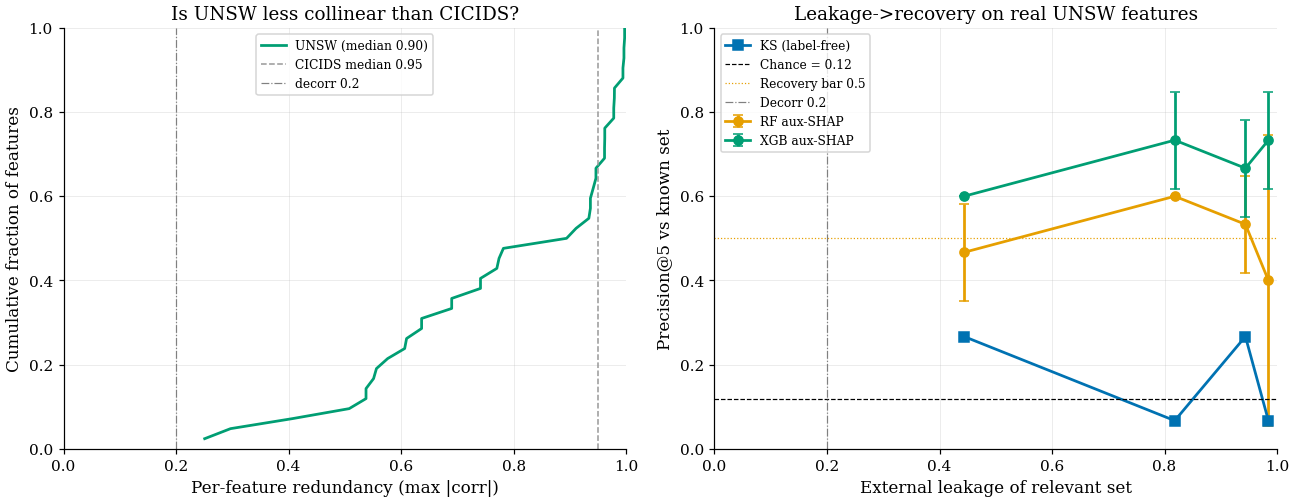

In [20]:
def agg(level, method, model, col='precision'):
    s = res[(res['level'] == level) & (res['method'] == method) & (res['model'] == model)][col]
    return float(s.mean()), float(s.std())
def meta(level, model, col):
    return float(res[(res['level'] == level) & (res['method'] == 'aux_shap') &
                     (res['model'] == model)][col].mean())

tbl = pd.DataFrame({
    'quantile': LEVEL_QUANTILES,
    'leakage': [round(LEVEL_LEAK[q], 3) for q in LEVEL_QUANTILES],
    'rf_shap': [round(agg(q, 'aux_shap', 'rf')[0], 3) for q in LEVEL_QUANTILES],
    'xgb_shap': [round(agg(q, 'aux_shap', 'xgb')[0], 3) for q in LEVEL_QUANTILES],
    'ks': [round(agg(q, 'ks', 'shared')[0], 3) for q in LEVEL_QUANTILES],
    'rf_recall': [round(meta(q, 'rf', 'aux_recall'), 3) for q in LEVEL_QUANTILES],
    'xgb_recall': [round(meta(q, 'xgb', 'aux_recall'), 3) for q in LEVEL_QUANTILES],
})
print('Leakage->recovery (precision@%d vs known set):' % K_PRIMARY)
print(tbl.to_string(index=False))
print(f'\nChance ~ {CHANCE:.3f}.')
tbl.to_csv(TABLES / '09_unsw_leakage_recovery.csv', index=False)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 4.8))

# Panel A: redundancy CDF, UNSW vs CICIDS reference
xs = np.sort(REDUNDANCY); ys = np.arange(1, len(xs) + 1) / len(xs)
axA.plot(xs, ys, color='#009E73', label=f'UNSW (median {unsw_med:.2f})')
axA.axvline(CIC_REF['median_redundancy'], ls='--', color='#999999', lw=1.0,
            label=f"CICIDS median {CIC_REF['median_redundancy']}")
axA.axvline(REAL_DECORR_MAX, ls='-.', color='grey', lw=0.8, label=f'decorr {REAL_DECORR_MAX}')
axA.set_xlabel('Per-feature redundancy (max |corr|)')
axA.set_ylabel('Cumulative fraction of features')
axA.set_xlim(0, 1.0); axA.set_ylim(0, 1.0)
axA.set_title('Is UNSW less collinear than CICIDS?')
axA.legend(fontsize=8)

# Panel B: leakage->recovery curve
xq = [LEVEL_LEAK[q] for q in LEVEL_QUANTILES]
for model in MODELS:
    ms = [agg(q, 'aux_shap', model)[0] for q in LEVEL_QUANTILES]
    es = [agg(q, 'aux_shap', model)[1] for q in LEVEL_QUANTILES]
    axB.errorbar(xq, ms, yerr=es, marker='o', capsize=3, color=MODEL_COLOR[model],
                 label=f'{model.upper()} aux-SHAP')
ksm = [agg(q, 'ks', 'shared')[0] for q in LEVEL_QUANTILES]
axB.plot(xq, ksm, marker='s', color=MODEL_COLOR['ks'], label='KS (label-free)')
axB.axhline(CHANCE, ls='--', color='black', lw=0.8, label=f'Chance = {CHANCE:.2f}')
axB.axhline(RECOVER_MIN, ls=':', color='#E69F00', lw=0.8, label=f'Recovery bar {RECOVER_MIN}')
axB.axvline(REAL_DECORR_MAX, ls='-.', color='grey', lw=0.8, label=f'Decorr {REAL_DECORR_MAX}')
axB.set_xlabel('External leakage of relevant set')
axB.set_ylabel(f'Precision@{K_PRIMARY} vs known set')
axB.set_xlim(0, 1.0); axB.set_ylim(0, 1.0)
axB.set_title('Leakage->recovery on real UNSW features')
axB.legend(fontsize=8)

fig.tight_layout(); save_figure(fig, '09_unsw_geometry_localization'); plt.show()

## 9. Pre-registered cross-dataset verdict (D025)

In [21]:
q_low = min(LEVEL_QUANTILES, key=lambda q: LEVEL_LEAK[q])
q_high = max(LEVEL_QUANTILES, key=lambda q: LEVEL_LEAK[q])
unsw_reached = LEVEL_LEAK[q_low] <= REAL_DECORR_MAX

per_model = {}
for model in MODELS:
    low_recall = meta(q_low, model, 'aux_recall')
    low_bal = meta(q_low, model, 'balance')
    low_valid = (low_recall >= RECALL_MIN) and (BALANCE_BAND[0] <= low_bal <= BALANCE_BAND[1])
    low_shap = agg(q_low, 'aux_shap', model)[0]
    high_shap = agg(q_high, 'aux_shap', model)[0]
    per_model[model] = {'low_recall': low_recall, 'low_valid': low_valid,
                        'low_shap': low_shap, 'trend': low_shap - high_shap,
                        'recovers': low_shap >= RECOVER_MIN}

any_recovers = any(unsw_reached and m['low_valid'] and m['recovers'] for m in per_model.values())
any_valid_norecover = any(unsw_reached and m['low_valid'] and not m['recovers']
                          for m in per_model.values())

if not unsw_reached:
    verdict = 'CROSS-DATASET-BLOCK'
elif any_recovers:
    verdict = 'MECHANISM-HOLDS-ON-REAL-DATA'
elif any_valid_norecover:
    verdict = 'SECOND-FACTOR-CONFIRMED'
else:
    verdict = 'INCONCLUSIVE'

print('=' * 74)
print('UNSW CROSS-DATASET VERDICT (D025)  -- precision@%d vs known set' % K_PRIMARY)
print('=' * 74)
print(f'  UNSW median redundancy {unsw_med:.3f} vs CICIDS {CIC_REF["median_redundancy"]}  |  '
      f'non-degenerate {unsw_nd}/{N_FEATURES} vs {CIC_REF["nondegen"]}/{CIC_REF["n_features"]}')
print(f'  min non-degenerate leakage {LEVEL_LEAK[q_low]:.3f}  '
      f'(reached <= {REAL_DECORR_MAX}: {unsw_reached}; CICIDS floor {CIC_REF["leakage_floor"]})')
for model in MODELS:
    m = per_model[model]
    print(f'  {model.upper()}: low-leak SHAP {m["low_shap"]:.3f} (recall {m["low_recall"]:.2f}, '
          f'valid {m["low_valid"]}, recovers {m["recovers"]}, trend {m["trend"]:+.3f})')
print(f'  chance {CHANCE:.3f}  |  RF vs XGB agree on recovery: '
      f'{per_model["rf"]["recovers"] == per_model["xgb"]["recovers"]}')
print('-' * 74)
print(f'--> VERDICT: {verdict}')
MSG = {
    'CROSS-DATASET-BLOCK': 'UNSW also cannot reach a decorrelated-and-non-degenerate set. '
        'The structural block generalizes; explanation localization is structurally hard '
        'across IDS datasets. The negative is now cross-dataset.',
    'MECHANISM-HOLDS-ON-REAL-DATA': 'UNSW reaches the regime and aux-SHAP recovers there '
        'with a valid model. The identifiability mechanism is validated on REAL data -- a '
        'conditions-of-validity result with a genuine real positive pole and a clean '
        'leakage->recovery curve.',
    'SECOND-FACTOR-CONFIRMED': 'UNSW reaches the regime with a learnable label, yet aux-SHAP '
        'fails -- real evidence of a second factor beyond correlation; qualifies the '
        'synthetic mechanism on real data.',
    'INCONCLUSIVE': 'Reached but construction invalid at the low-leak level; tighten the '
        'non-degeneracy filter and re-run.',
}[verdict]
print('   ' + MSG)

UNSW CROSS-DATASET VERDICT (D025)  -- precision@5 vs known set
  UNSW median redundancy 0.903 vs CICIDS 0.95  |  non-degenerate 29/42 vs 63/82
  min non-degenerate leakage 0.444  (reached <= 0.2: False; CICIDS floor 0.248)
  RF: low-leak SHAP 0.467 (recall 0.99, valid True, recovers False, trend +0.067)
  XGB: low-leak SHAP 0.600 (recall 0.99, valid True, recovers True, trend -0.133)
  chance 0.119  |  RF vs XGB agree on recovery: False
--------------------------------------------------------------------------
--> VERDICT: CROSS-DATASET-BLOCK
   UNSW also cannot reach a decorrelated-and-non-degenerate set. The structural block generalizes; explanation localization is structurally hard across IDS datasets. The negative is now cross-dataset.


In [22]:
SUMMARY = {
    'generated': datetime.datetime.now().isoformat(timespec='seconds'),
    'dataset': 'UNSW-NB15', 'unsw_file': str(path), 'n_features': N_FEATURES,
    'seeds': SEEDS, 'rel_size': REL_SIZE, 'chance': CHANCE, 'models': MODELS,
    'geometry': {'median_redundancy': unsw_med, 'non_degenerate': unsw_nd,
                 'nd_below_decorr': int((NONDEGEN & (REDUNDANCY < REAL_DECORR_MAX)).sum()),
                 'modal_max': MODAL_MAX, 'min_distinct': MIN_DISTINCT},
    'levels': [{'quantile': q, 'leakage': LEVEL_LEAK[q],
                'rf_shap': agg(q, 'aux_shap', 'rf')[0], 'xgb_shap': agg(q, 'aux_shap', 'xgb')[0],
                'ks': agg(q, 'ks', 'shared')[0],
                'rf_recall': meta(q, 'rf', 'aux_recall'), 'xgb_recall': meta(q, 'xgb', 'aux_recall')}
               for q in LEVEL_QUANTILES],
    'min_leakage': float(min(LEVEL_LEAK.values())), 'reached': bool(unsw_reached),
    'per_model': {k: {kk: (float(vv) if isinstance(vv, (int, float, np.floating)) else bool(vv))
                      for kk, vv in v.items()} for k, v in per_model.items()},
    'verdict': verdict, 'cicids_reference': CIC_REF,
}
with open(SUMMARY_JSON, 'w') as f:
    json.dump(SUMMARY, f, indent=2, default=str)
print(f'Saved {SUMMARY_JSON}')

log_finding(
    finding_id='F013',
    title='UNSW-NB15 geometry + controlled localization across RF and XGBoost (cross-dataset)',
    context='04_phase2_multidataset/09_unsw_geometry_localization',
    what_we_did=(
        'Applied the Phase-1 protocol to UNSW-NB15 and across RF + XGBoost: characterized '
        'feature redundancy and degeneracy (vs CICIDS), tested whether a decorrelated-and-'
        'non-degenerate set is reachable, and ran the controlled known-GT leakage->recovery '
        'sweep on real UNSW features (concept arm, recover S2), gating on recall + balance. '
        'D025.'
    ),
    what_we_found=(
        'Verdict: ' + verdict + '. UNSW median redundancy %.3f vs CICIDS %.2f; non-degenerate '
        '%d/%d vs %d/%d. Min non-degenerate external leakage %.3f (reached <= %.2f: %s; CICIDS '
        'floor %.3f). At the lowest-leakage level: RF aux-SHAP %.3f (recall %.2f), XGB aux-SHAP '
        '%.3f (recall %.2f), KS %.3f, chance %.3f. RF vs XGB agree on recovery: %s.'
        % (unsw_med, CIC_REF['median_redundancy'], unsw_nd, N_FEATURES, CIC_REF['nondegen'],
           CIC_REF['n_features'], LEVEL_LEAK[q_low], REAL_DECORR_MAX, str(bool(unsw_reached)),
           CIC_REF['leakage_floor'], per_model['rf']['low_shap'], per_model['rf']['low_recall'],
           per_model['xgb']['low_shap'], per_model['xgb']['low_recall'],
           agg(q_low, 'ks', 'shared')[0], CHANCE,
           str(per_model['rf']['recovers'] == per_model['xgb']['recovers']))
    ),
    why_it_matters=(
        'First breadth result. Determines whether the CICIDS structural block (no '
        'identifiable localization target) is dataset-specific or general, whether the '
        'identifiability mechanism holds on real data when the geometry permits the test, and '
        'whether the picture is model-class-dependent (RF vs XGBoost). This is the '
        'generalization the Q1 cross-dataset claim rests on.'
    ),
)
print('F013 logged. Record the call in a hand journal entry.')

Saved /content/drive/MyDrive/phd_thesis/data/processed/phase2_09_unsw_geometry.json
[FINDING LOGGED] F013: UNSW-NB15 geometry + controlled localization across RF and XGBoost (cross-dataset)
F013 logged. Record the call in a hand journal entry.


## 10. What this settles, and what is next

- **CROSS-DATASET-BLOCK** generalizes the Phase-1 negative: explanation localization is
  structurally hard on real IDS feature geometry across datasets and model classes. The
  thesis ships the two-dimensional diagnostic (redundancy + degeneracy) as a measurable
  property that predicts this, now validated as *descriptive* across two datasets.
- **MECHANISM-HOLDS-ON-REAL-DATA** is the positive pole the thesis has been missing: the
  identifiability mechanism, confirmed synthetically in 07g, also holds on real UNSW
  features where the geometry permits — a genuine conditions-of-validity result with a clean
  real-data leakage->recovery curve and a deployment diagnostic that is now *predictive*,
  not just motivated.
- **SECOND-FACTOR-CONFIRMED** would be the most interesting: a real, learnable, decorrelated
  target on which SHAP still fails — qualifying the mechanism and pointing to a further
  cause; worth a focused follow-up.

Either way the model-breadth sub-result (RF vs XGBoost agreement) feeds the C3 robustness
claim. **Next notebooks:** (a) the real attack-family-holdout *distributional* benchmark on
UNSW (KS vs SHAP on actual drift, replicating the redundancy benchmark with the least-biased
available ground truth); (b) optionally a third dataset (CSE-CIC-IDS-2018 reserve or an IoT
set) if 2-of-3 generalization is wanted. The deferred adaptation/efficiency experiment (08)
remains optional.

Record the call by hand:

In [23]:
# add_journal_entry(
#     title='Notebook 09 UNSW geometry + cross-model localization verdict',
#     body='...UNSW vs CICIDS redundancy/degeneracy, reachability, the RF/XGB leakage->recovery '
#          'curve, the verdict tier, and what it implies for cross-dataset generalization.',
# )